In [7]:
import json
import math
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

from chengyu.evaluation import charger_dico, normaliser, idiomes_presents

plt.rcParams["figure.figsize"] = (8, 4) 

Nombre d'idiomes : 31114
  longueur 3 :    126 idiomes (0.4 %)
  longueur 4 :  29683 idiomes (95.4 %)
  longueur 5 :    322 idiomes (1.0 %)
  longueur 6 :    194 idiomes (0.6 %)
  longueur 7 :    240 idiomes (0.8 %)
  longueur 8 :     30 idiomes (0.1 %)
  longueur 9 :    422 idiomes (1.4 %)
  longueur 10 :     12 idiomes (0.0 %)
  longueur 11 :     70 idiomes (0.2 %)
  longueur 12 :      4 idiomes (0.0 %)
  longueur 13 :      7 idiomes (0.0 %)
  longueur 15 :      4 idiomes (0.0 %)


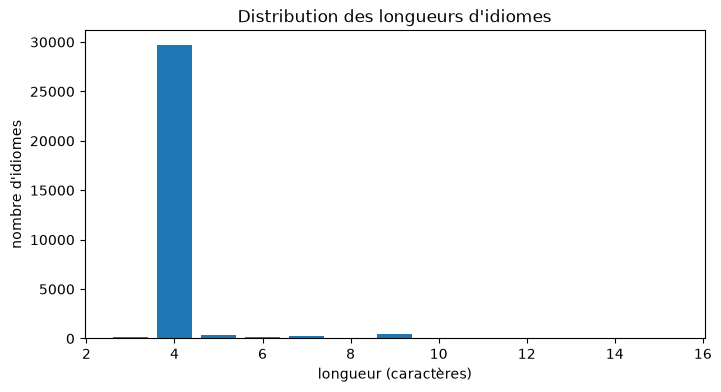

In [10]:
dico, longueurs = charger_dico()
print(f"Nombre d'idiomes : {len(dico)}")

dist_long = Counter(len(i) for i in dico)
for L in sorted(dist_long):
    print(f"  longueur {L} : {dist_long[L]:>6} idiomes ({100*dist_long[L]/len(dico):.1f} %)")

plt.bar(dist_long.keys(), dist_long.values())
plt.xlabel("longueur (caractères)"); plt.ylabel("nombre d'idiomes")
plt.title("Distribution des longueurs d'idiomes")
plt.show()

In [9]:
import os
os.chdir(os.path.expanduser("~/projet-memoire"))
print("cwd :", os.getcwd())

cwd : /home/fatin/projet-memoire


Lignes : 95560   Colonnes : ['src', 'dst']
src avec espaces : 100.0 %


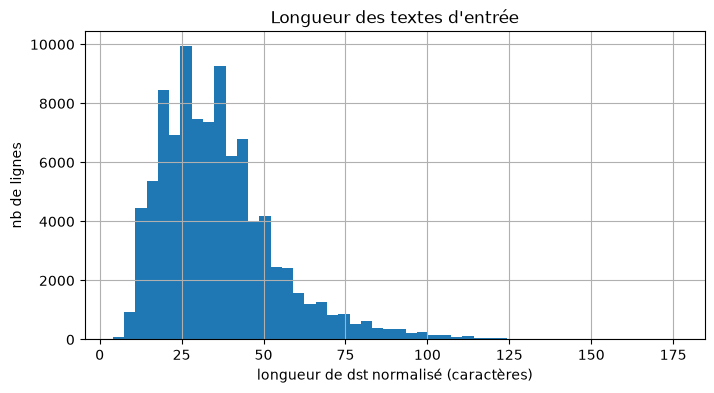

count    95560.000000
mean        36.146097
std         17.764932
min          4.000000
25%         23.000000
50%         33.000000
75%         44.000000
max        176.000000
Name: dst_norm_len, dtype: float64

In [11]:
df = pd.read_csv("data/raw/cip/train.csv")
print(f"Lignes : {len(df)}   Colonnes : {list(df.columns)}")

avec_espaces = df["src"].astype(str).str.contains(" ").mean()
print(f"src avec espaces : {100*avec_espaces:.1f} %")

df["dst_norm_len"] = df["dst"].astype(str).map(lambda s: len(normaliser(s)))
df["dst_norm_len"].hist(bins=50)
plt.xlabel("longueur de dst normalisé (caractères)"); plt.ylabel("nb de lignes")
plt.title("Longueur des textes d'entrée")
plt.show()
df["dst_norm_len"].describe()

In [12]:
nb_candidats = []
for src, dst in zip(df["src"], df["dst"]):
    s, d = normaliser(src), normaliser(dst)
    cands = idiomes_presents(s, dico, longueurs) - idiomes_presents(d, dico, longueurs)
    nb_candidats.append(len(cands))

c = Counter(nb_candidats)
print("candidats -> nb de lignes :", dict(sorted(c.items())))
propres = c[1]
print(f"Exploitables (1 candidat) : {propres} ({100*propres/len(df):.1f} %)")
print(f"Perdues (0 ou >=2)        : {len(df)-propres} ({100*(len(df)-propres)/len(df):.1f} %)")


candidats -> nb de lignes : {0: 804, 1: 90079, 2: 4323, 3: 323, 4: 28, 5: 2, 7: 1}
Exploitables (1 candidat) : 90079 (94.3 %)
Perdues (0 ou >=2)        : 5481 (5.7 %)


Idiomes vus : 7723 / 31114 (24.8 %)
Compte max : 68   médiane : 7
Top 10 : [('无论如何', 68), ('引人注目', 67), ('视而不见', 62), ('方便之门', 62), ('自以为是', 60), ('同日而语', 60), ('肆无忌惮', 59), ('众所周知', 57), ('截然不同', 56), ('逍遥法外', 54)]


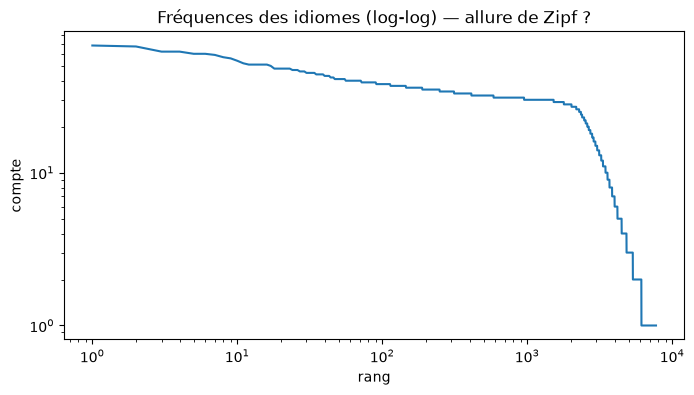

vus 1 fois : 1603 | 2 fois : 778 | >=10 fois : 3573


In [13]:
with open("data/freq_idiomes.json", encoding="utf-8") as f:
    freq = json.load(f)

print(f"Idiomes vus : {len(freq)} / {len(dico)} ({100*len(freq)/len(dico):.1f} %)")

comptes = sorted(freq.values(), reverse=True)
print(f"Compte max : {comptes[0]}   médiane : {comptes[len(comptes)//2]}")
print("Top 10 :", sorted(freq.items(), key=lambda kv: -kv[1])[:10])

plt.loglog(range(1, len(comptes)+1), comptes)
plt.xlabel("rang"); plt.ylabel("compte")
plt.title("Fréquences des idiomes (log-log) — allure de Zipf ?")
plt.show()

dist_comptes = Counter(freq.values())
print("vus 1 fois :", dist_comptes.get(1, 0),
      "| 2 fois :", dist_comptes.get(2, 0),
      "| >=10 fois :", sum(v for k, v in dist_comptes.items() if k >= 10))

In [14]:
T = sum(freq.values())      # total des comptes
N = len(dico)               # taille du dictionnaire
n_jamais_vus = N - len(freq)

masse_jamais_vus = n_jamais_vus / (T + N)
print(f"T = {T}, N = {N}")
print(f"Masse des {n_jamais_vus} idiomes jamais vus : {100*masse_jamais_vus:.1f} %")

log_max = math.log((comptes[0] + 1) / (T + N))
log_min = math.log(1 / (T + N))
print(f"log-prior max : {log_max:.2f}   min : {log_min:.2f}   écart : {log_max-log_min:.2f} nats")

T = 103569, N = 31114
Masse des 23391 idiomes jamais vus : 17.4 %
log-prior max : -7.58   min : -11.81   écart : 4.23 nats
